# Capítulo 11 — Soluções dos exercícios complementares

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

> **Para o professor.** Soluções dos teóricos **T1–T5** e numéricos **N1–N4** do Cap. 11. Não distribuir antes da entrega.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

R_T, Omega, S0, g = 6.371e6, 7.292e-5, 1361.0, 9.8

## T1 — O transporte exigido e o teste dos 90°

**Solução.** Em regime estacionário, a energia que entra numa calota polar limitada por $\phi$ deve sair por transporte através de $\phi$: $T(\phi) = \int(Q_{abs} - OLR)\,dA$ na calota ao sul. Como o planeta inteiro está (quase) em equilíbrio, $\int$ global $= 0$ — logo $T(90°N) = 0$: qualquer resíduo denuncia perfis inconsistentes (ou um planeta esquentando — que é exatamente o desequilíbrio de ~1 W/m² do aquecimento global, Cap. 21).

## T2 — O jato de momento angular

In [2]:
# M = (ΩR cosφ + u) R cosφ conservado; parte do repouso no equador: M = ΩR²
phi_, Om_, Rr_ = sp.symbols('phi Omega R', positive=True)
u_am = sp.solve(sp.Eq((Om_*Rr_*sp.cos(phi_) + sp.Symbol('u'))*Rr_*sp.cos(phi_),
                      Om_*Rr_**2), sp.Symbol('u'))[0]
display(sp.Eq(sp.Symbol('u'), sp.simplify(u_am)))
for lat in [10, 20, 30]:
    u = Omega*R_T*np.sin(np.deg2rad(lat))**2/np.cos(np.deg2rad(lat))
    print(f'φ = {lat}°: u = {u:6.1f} m/s')
print('\nEm 30° já são 134 m/s — cisalhamento tão violento que o escoamento')
print('fica baroclinicamente/inercialmente instável: a célula É OBRIGADA a')
print('parar por ali e entregar o transporte aos turbilhões (ciclones).')

Eq(u, Omega*R*sin(phi)**2/cos(phi))

φ = 10°: u =   14.2 m/s
φ = 20°: u =   57.8 m/s
φ = 30°: u =  134.1 m/s

Em 30° já são 134 m/s — cisalhamento tão violento que o escoamento
fica baroclinicamente/inercialmente instável: a célula É OBRIGADA a
parar por ali e entregar o transporte aos turbilhões (ciclones).


## T3 — Vento térmico

In [3]:
# derivação simbólica: u_g = -(1/ρf) ∂P/∂y; hidrostática ∂P/∂z = -ρg; gás ideal
x, y, z_ = sp.symbols('x y z')
f_, Rd_, g_ = sp.symbols('f R_d g', positive=True)
P = sp.Function('P')(y, z_)
T = sp.Function('T')(y, z_)
rho = P/(Rd_*T)
ug = -1/(rho*f_)*sp.diff(P, y)
dugdz = sp.diff(ug, z_)
# substituir ∂P/∂z = -ρ g e simplificar mantendo termos dominantes:
dugdz = dugdz.subs(sp.Derivative(P, z_), -rho*g_)
dugdz = sp.simplify(sp.expand(dugdz))
print('∂u_g/∂z =', dugdz)
print('\nO termo dominante é -(g/fT)·∂T/∂y (o outro, com ∂P/∂y·g/RdT²... cancela')
print('na aproximação de pequena inclinação das isóbaras). No HS (f<0), ar frio')
print('ao SUL dá ∂T/∂y>0 e ∂u_g/∂z>0: oeste crescendo com a altura ✓')

∂u_g/∂z =

 (-R_d*(g*P(y, z)*Derivative(T(y, z), y)/(R_d*T(y, z)**2) - g*Derivative(P(y, z), y)/(R_d*T(y, z)))*T(y, z) - R_d*Derivative(P(y, z), y)*Derivative(T(y, z), z) - g*Derivative(P(y, z), y))/(f*P(y, z))

O termo dominante é -(g/fT)·∂T/∂y (o outro, com ∂P/∂y·g/RdT²... cancela
na aproximação de pequena inclinação das isóbaras). No HS (f<0), ar frio
ao SUL dá ∂T/∂y>0 e ∂u_g/∂z>0: oeste crescendo com a altura ✓


## T4 — A restauração β

**Solução (heurística).** Parcela em $y_0$ com $\zeta = 0$ deslocada $+y'$: conserva $\zeta + f$, logo adquire $\zeta = -\beta y' < 0$ (giro horário no HN). Numa cadeia senoidal $y' = A\sin(kx)$, essa vorticidade induzida gera meridionais que empurram a cadeia para **oeste** (o padrão de fase retrograda). Quantitativamente a vorticidade induzida $-\beta y'$ e a relação $\zeta' = -k^2\psi'$ dão $c - U = -\beta/k^2$. ∎

## T5 — Ondas estacionárias

In [4]:
phi0 = -50.0
beta = 2*Omega*np.cos(np.deg2rad(phi0))/R_T
circ = 2*np.pi*R_T*np.cos(np.deg2rad(phi0))
for U in [10, 15, 25]:
    lam = 2*np.pi*np.sqrt(U/beta)
    print(f'U = {U:2d} m/s: λ_est = {lam/1e6:4.1f} mil km → '
          f'{circ/lam:.1f} ondas no círculo de latitude')
print('\n4–6 ondas planetárias — exatamente o número de cristas/cavados das')
print('cartas de 500 hPa do HS. ✓')

U = 10 m/s: λ_est =  5.2 mil km → 5.0 ondas no círculo de latitude
U = 15 m/s: λ_est =  6.3 mil km → 4.1 ondas no círculo de latitude
U = 25 m/s: λ_est =  8.2 mil km → 3.1 ondas no círculo de latitude

4–6 ondas planetárias — exatamente o número de cristas/cavados das
cartas de 500 hPa do HS. ✓


---
## N1 — Transporte com calotas geladas

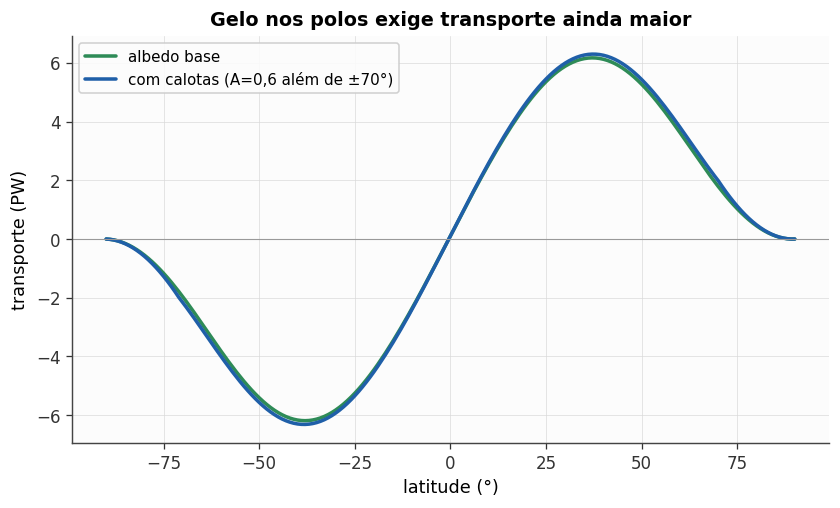

pico: base 6.2 PW → com gelo 6.3 PW


In [5]:
Phi_r, d_r, d_y = np.deg2rad(23.44), 173, 365.25
def insol(phi, d):
    dl = Phi_r*np.cos(2*np.pi*(d - d_r)/d_y)
    h0 = np.arccos(np.clip(-np.tan(phi)*np.tan(dl), -1, 1))
    return S0/np.pi*(h0*np.sin(phi)*np.sin(dl) + np.cos(phi)*np.cos(dl)*np.sin(h0))

lat = np.linspace(-90, 90, 181); phi = np.deg2rad(lat)
dias = np.arange(1, 366)
Q_an = np.array([np.mean([insol(p, d) for d in dias]) for p in phi])

def transporte(albedo):
    Q_abs = (1 - albedo)*Q_an
    OLR = np.full_like(Q_abs, 0.0) + Q_abs.mean()
    OLR = 238.0 + 25.0*(np.cos(phi)**2 - 2/3)
    OLR += np.average(Q_abs, weights=np.cos(phi)) - np.average(OLR, weights=np.cos(phi))
    dphi = np.deg2rad(1.0)
    return np.cumsum((Q_abs - OLR)*2*np.pi*R_T**2*np.cos(phi)*dphi)/1e15

alb_base = 0.30 + 0.25*np.sin(phi)**4
alb_gelo = np.where(np.abs(lat) > 70, 0.60, alb_base)
T_base, T_gelo = transporte(alb_base), transporte(alb_gelo)

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(lat, T_base, color=CORES['verde'], label='albedo base')
ax.plot(lat, T_gelo, color=CORES['azul'], label='com calotas (A=0,6 além de ±70°)')
ax.axhline(0, color='#999999', lw=0.7)
ax.set(xlabel='latitude (°)', ylabel='transporte (PW)',
       title='Gelo nos polos exige transporte ainda maior')
ax.legend()
plt.show()
print(f'pico: base {np.max(np.abs(T_base)):.1f} PW → com gelo '
      f'{np.max(np.abs(T_gelo)):.1f} PW')

## N2 — Varredura de $D$ no EBM

Integrating for 900 steps, 3652.4220000000005 days, or 10 years.


Total elapsed time is 9.999999999999863 years.
Integrating for 900 steps, 3652.4220000000005 days, or 10 years.


Total elapsed time is 9.999999999999863 years.
Integrating for 900 steps, 3652.4220000000005 days, or 10 years.


Total elapsed time is 9.999999999999863 years.
Integrating for 900 steps, 3652.4220000000005 days, or 10 years.


Total elapsed time is 9.999999999999863 years.
Integrating for 900 steps, 3652.4220000000005 days, or 10 years.


Total elapsed time is 9.999999999999863 years.


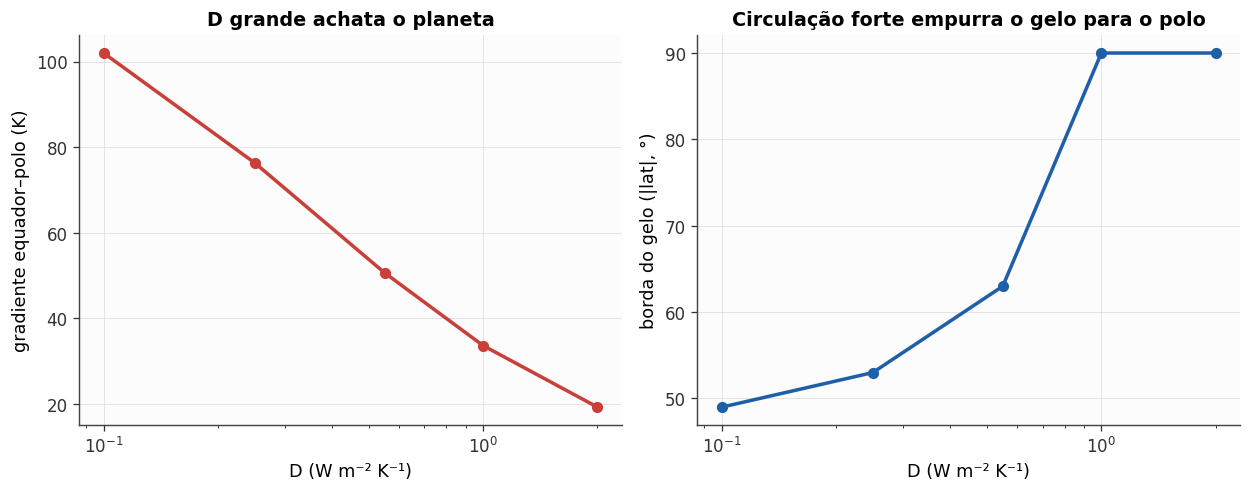

D→0: cada latitude em equilíbrio radiativo local (gradiente enorme);
D→∞: planeta isotérmico. O real (D≈0,55) fica no meio — e é o valor
que o EBM precisa para imitar os 5 PW do Caso 1.


In [6]:
import warnings; warnings.filterwarnings('ignore', message='Cannot import')
import climlab

Ds = [0.1, 0.25, 0.55, 1.0, 2.0]
grad, lat_gelo = [], []
for D in Ds:
    ebm = climlab.EBM_annual(num_lat=90, D=D)
    ebm.integrate_years(10)
    Ts = np.squeeze(ebm.Ts)
    grad.append(Ts.max() - Ts.min())
    frio = np.where(Ts < -10)[0]
    lat_gelo.append(abs(ebm.lat[frio]).min() if frio.size else 90.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))
ax1.semilogx(Ds, grad, 'o-', color=CORES['vermelho'])
ax1.set(xlabel='D (W m⁻² K⁻¹)', ylabel='gradiente equador–polo (K)',
        title='D grande achata o planeta')
ax2.semilogx(Ds, lat_gelo, 'o-', color=CORES['azul'])
ax2.set(xlabel='D (W m⁻² K⁻¹)', ylabel='borda do gelo (|lat|, °)',
        title='Circulação forte empurra o gelo para o polo')
fig.tight_layout(); plt.show()
print('D→0: cada latitude em equilíbrio radiativo local (gradiente enorme);')
print('D→∞: planeta isotérmico. O real (D≈0,55) fica no meio — e é o valor')
print('que o EBM precisa para imitar os 5 PW do Caso 1.')

## N3 — $k$ estacionário numérico

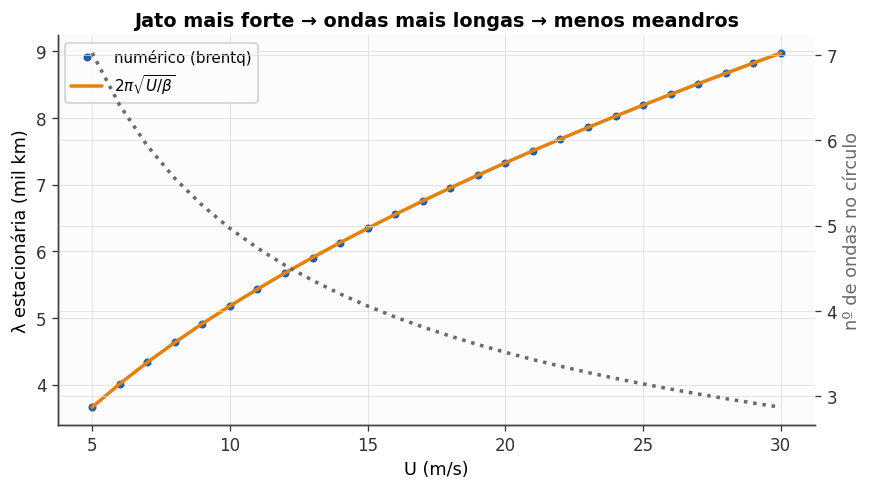

In [7]:
from scipy.optimize import brentq
phi0 = -50.0
beta = 2*Omega*np.cos(np.deg2rad(phi0))/R_T
circ = 2*np.pi*R_T*np.cos(np.deg2rad(phi0))

Us = np.linspace(5, 30, 26)
lam_num = [2*np.pi/brentq(lambda k: U - beta/k**2, 1e-7, 1e-4) for U in Us]
lam_teo = 2*np.pi*np.sqrt(Us/beta)

fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.plot(Us, np.array(lam_num)/1e6, 'o', color=CORES['azul'], ms=4,
        label='numérico (brentq)')
ax.plot(Us, lam_teo/1e6, '-', color=CORES['laranja'], label='$2\\pi\\sqrt{U/\\beta}$')
ax2 = ax.twinx()
ax2.plot(Us, circ/lam_teo, ':', color=CORES['cinza'])
ax2.set_ylabel('nº de ondas no círculo', color=CORES['cinza'])
ax.set(xlabel='U (m/s)', ylabel='λ estacionária (mil km)',
       title='Jato mais forte → ondas mais longas → menos meandros')
ax.legend()
plt.show()

## N4 — Zona baroclínica larga × estreita

In [8]:
lat_g = np.linspace(-80, -10, 90)
z_g = np.linspace(0, 16e3, 90)
LAT, Z = np.meshgrid(lat_g, z_g)

def jato_de(escala):
    T_sfc = 300.0 - 45.0*0.5*(1 + np.tanh((LAT + 50)/(-escala)))
    T = np.maximum(T_sfc - 6.5e-3*Z, 210.0)
    f = 2*Omega*np.sin(np.deg2rad(LAT))
    dTdy = np.gradient(T, np.deg2rad(lat_g)*R_T, axis=1)
    u = np.cumsum(-g/(f*T)*dTdy, axis=0)*(z_g[1]-z_g[0])
    return u

for esc, nome in [(12.0, 'estreita (12°)'), (24.0, 'larga (24°)')]:
    u = jato_de(esc)
    i, j = np.unravel_index(np.argmax(u), u.shape)
    print(f'zona {nome:15s}: jato de {u.max():5.1f} m/s em '
          f'{lat_g[j]:.0f}°, {z_g[i]/1e3:.0f} km')
print('\nMesmo ΔT total espalhado no dobro da largura → metade do ∂T/∂y →')
print('metade do cisalhamento térmico → jato ~2× mais fraco (e mais largo).')

zona estreita (12°) : jato de  67.2 m/s em -47°, 11 km
zona larga (24°)    : jato de  35.8 m/s em -41°, 12 km

Mesmo ΔT total espalhado no dobro da largura → metade do ∂T/∂y →
metade do cisalhamento térmico → jato ~2× mais fraco (e mais largo).


---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*